# Market Basket Analysis Setup

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules

import time

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("cleaned_online_retail.csv")

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print("Shape:", df.shape)
df.head()

Shape: (397924, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [65]:
# Group items per invoice (transaction) Convert into binary (1 = purchased, 0 = not purchased)

basket = (
    df.groupby(['InvoiceNo', 'Description'])['Quantity']
    .sum()
    .unstack(fill_value=0)
    .gt(0)
    .astype('int8')
)
basket = basket.loc[:, basket.sum() > 10]
print("Basket Shape:", basket.shape)
basket.head()

Basket Shape: (18536, 2889)


Description   4 PURPLE FLOCK DINNER CANDLES   50'S CHRISTMAS GIFT BAG LARGE   DOLLY GIRL BEAKER   I LOVE LONDON MINI BACKPACK   NINE DRAWER OFFICE TIDY   OVAL WALL MIRROR DIAMANTE    RED SPOT GIFT BAG LARGE   SET 2 TEA TOWELS I LOVE LONDON    SPACEBOY BABY GIFT SET   TRELLIS COAT RACK  10 COLOUR SPACEBOY PEN  12 COLOURED PARTY BALLOONS  12 DAISY PEGS IN WOOD BOX  12 EGG HOUSE PAINTED WOOD  12 IVORY ROSE PEG PLACE SETTINGS  12 MESSAGE CARDS WITH ENVELOPES  12 PENCIL SMALL TUBE WOODLAND  12 PENCILS SMALL TUBE RED RETROSPOT  12 PENCILS SMALL TUBE SKULL  12 PENCILS TALL TUBE POSY  12 PENCILS TALL TUBE RED RETROSPOT  12 PENCILS TALL TUBE SKULLS  12 PENCILS TALL TUBE WOODLAND  12 PINK HEN+CHICKS IN BASKET  12 PINK ROSE PEG PLACE SETTINGS  12 RED ROSE PEG PLACE SETTINGS  15CM CHRISTMAS GLASS BALL 20 LIGHTS  16 PIECE CUTLERY SET PANTRY DESIGN  18PC WOODEN CUTLERY SET DISPOSABLE  2 PICTURE BOOK EGGS EASTER BUNNY  2 PICTURE BOOK EGGS EASTER CHICKS  2 PICTURE BOOK EGGS EASTER DUCKS  \
InvoiceNo                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   
536365                                    0                               0                   0                             0                         0                            0                         0                                 0                        0                   0                       0                           0                          0                          0                                 0                                0                              0                                    0                            0                          0                                   0                            0                              0                             0                                0                               0                                    0                                   0                                   0                                 0                                  0                                 0   
536366                                    0                               0                   0                             0                         0                            0                         0                                 0                        0                   0                       0                           0                          0                          0                                 0                                0                              0                                    0                            0                          0                                   0                            0                              0                             0                                0                               0                                    0                                   0                                   0                                 0                                  0                                 0   
536367                                    0 

In [5]:
# Calculate support manually
support = basket.sum() / len(basket)

support_df = pd.DataFrame({
    'Item': support.index,
    'Support': support.values
}).sort_values(by='Support', ascending=False)

support_df.head(10)

,Item,Support
2759,WHITE HANGING HEART T-LIGHT HOLDER,0.106334
2027,REGENCY CAKESTAND 3 TIER,0.091929
1298,JUMBO BAG RED RETROSPOT,0.086319
1741,PARTY BUNTING,0.074450
161,ASSORTED COLOUR BIRD ORNAMENT,0.074180
1422,LUNCH BAG RED RETROSPOT,0.069486
2211,SET OF 3 CAKE TINS PANTRY DESIGN,0.061826
1910,POSTAGE,0.059290
1414,LUNCH BAG BLACK SKULL.,0.056754
1681,PACK OF 72 RETROSPOT CAKE CASES,0.055514


In [ ]:
MIN_SUPPORT = 0.01  

frequent_items = support[support >= MIN_SUPPORT]

print("Number of frequent items:", len(frequent_items))

Number of frequent items: 620


In [7]:
start_time_ap = time.time()

frequent_itemsets_apriori = apriori(
    basket,
    min_support=0.01,
    use_colnames=True
)

end_time_ap = time.time()
apriori_time = end_time_ap - start_time_ap
print("Apriori Runtime:", apriori_time)
frequent_itemsets_apriori.head()

Apriori Runtime: 123.12659049034119


,support,itemsets
0,0.010358,frozenset({ SET 2 TEA TOWELS I LOVE LONDON })
1,0.013056,frozenset({10 COLOUR SPACEBOY PEN})
2,0.010088,frozenset({12 MESSAGE CARDS WITH ENVELOPES})
3,0.014890,frozenset({12 PENCIL SMALL TUBE WOODLAND})
4,0.016562,frozenset({12 PENCILS SMALL TUBE RED RETROSPOT})


In [8]:
rules_apriori = association_rules(
    frequent_itemsets_apriori,
    metric="confidence",
    min_threshold=0.3
)

rules_apriori = rules_apriori.sort_values(by='lift', ascending=False)

rules_apriori.head(10)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
364,frozenset({REGENCY TEA PLATE GREEN }),frozenset({REGENCY TEA PLATE PINK}),0.014566,0.012085,0.010898,0.748148,61.909259,1.0,0.010722,3.922605,0.998390,0.691781,0.745067,0.824967
365,frozenset({REGENCY TEA PLATE PINK}),frozenset({REGENCY TEA PLATE GREEN }),0.012085,0.014566,0.010898,0.901786,61.909259,1.0,0.010722,10.033507,0.995882,0.691781,0.900334,0.824967
588,frozenset({POPPY'S PLAYHOUSE LIVINGROOM }),"frozenset({POPPY'S PLAYHOUSE BEDROOM , POPPY'S...",0.013595,0.013703,0.010035,0.738095,53.863517,1.0,0.009848,3.765861,0.994961,0.581250,0.734456,0.735189
583,"frozenset({POPPY'S PLAYHOUSE BEDROOM , POPPY'S...",frozenset({POPPY'S PLAYHOUSE LIVINGROOM }),0.013703,0.013595,0.010035,0.732283,53.863517,1.0,0.009848,3.684512,0.995070,0.581250,0.728594,0.735189
358,frozenset({REGENCY MILK JUG PINK }),frozenset({REGENCY SUGAR BOWL GREEN}),0.014674,0.014458,0.011114,0.757353,52.381694,1.0,0.010901,4.061626,0.995518,0.616766,0.753793,0.763005
359,frozenset({REGENCY SUGAR BOWL GREEN}),frozenset({REGENCY MILK JUG PINK }),0.014458,0.014674,0.011114,0.768657,52.381694,1.0,0.010901,4.259150,0.995300,0.616766,0.765211,0.763005
585,"frozenset({POPPY'S PLAYHOUSE KITCHEN, POPPY'S ...",frozenset({POPPY'S PLAYHOUSE BEDROOM }),0.011599,0.017048,0.010035,0.865116,50.746188,1.0,0.009837,7.287403,0.991798,0.539130,0.862777,0.726862
586,frozenset({POPPY'S PLAYHOUSE BEDROOM }),"frozenset({POPPY'S PLAYHOUSE KITCHEN, POPPY'S ...",0.017048,0.011599,0.010035,0.588608,50.746188,1.0,0.009837,2.402575,0.997296,0.539130,0.583780,0.726862
368,frozenset({REGENCY TEA PLATE ROSES }),frozenset({REGENCY TEA PLATE PINK}),0.017695,0.012085,0.010628,0.600610,49.700457,1.0,0.010414,2.473559,0.997531,0.554930,0.595724,0.740037
369,frozenset({REGENCY TEA PLATE PINK}),frozenset({REGENCY TEA PLATE ROSES }),0.012085,0.017695,0.010628,0.879464,49.700457,1.0,0.010414,8.149491,0.991866,0.554930,0.877293,0.740037


In [9]:
start_time_fp = time.time()

frequent_itemsets_fp = fpgrowth(
    basket,
    min_support=0.01,
    use_colnames=True
)

end_time_fp = time.time()
fp_time = end_time_fp - start_time_fp 
print("FP-Growth Runtime:", fp_time)
frequent_itemsets_fp.head()

FP-Growth Runtime: 2.7306969165802


,support,itemsets
0,0.106334,frozenset({WHITE HANGING HEART T-LIGHT HOLDER})
1,0.017318,frozenset({RED WOOLLY HOTTIE WHITE HEART.})
2,0.017210,frozenset({KNITTED UNION FLAG HOT WATER BOTTLE})
3,0.016023,frozenset({SET 7 BABUSHKA NESTING BOXES})
4,0.013002,frozenset({CREAM CUPID HEARTS COAT HANGER})


In [10]:
rules_fp = association_rules(
    frequent_itemsets_fp,
    metric="confidence",
    min_threshold=0.3
)

rules_fp.sort_values(by='lift', ascending=False).head(10)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
577,frozenset({REGENCY TEA PLATE PINK}),frozenset({REGENCY TEA PLATE GREEN }),0.012085,0.014566,0.010898,0.901786,61.909259,1.0,0.010722,10.033507,0.995882,0.691781,0.900334,0.824967
576,frozenset({REGENCY TEA PLATE GREEN }),frozenset({REGENCY TEA PLATE PINK}),0.014566,0.012085,0.010898,0.748148,61.909259,1.0,0.010722,3.922605,0.998390,0.691781,0.745067,0.824967
394,frozenset({POPPY'S PLAYHOUSE LIVINGROOM }),"frozenset({POPPY'S PLAYHOUSE BEDROOM , POPPY'S...",0.013595,0.013703,0.010035,0.738095,53.863517,1.0,0.009848,3.765861,0.994961,0.581250,0.734456,0.735189
389,"frozenset({POPPY'S PLAYHOUSE BEDROOM , POPPY'S...",frozenset({POPPY'S PLAYHOUSE LIVINGROOM }),0.013703,0.013595,0.010035,0.732283,53.863517,1.0,0.009848,3.684512,0.995070,0.581250,0.728594,0.735189
573,frozenset({REGENCY SUGAR BOWL GREEN}),frozenset({REGENCY MILK JUG PINK }),0.014458,0.014674,0.011114,0.768657,52.381694,1.0,0.010901,4.259150,0.995300,0.616766,0.765211,0.763005
572,frozenset({REGENCY MILK JUG PINK }),frozenset({REGENCY SUGAR BOWL GREEN}),0.014674,0.014458,0.011114,0.757353,52.381694,1.0,0.010901,4.061626,0.995518,0.616766,0.753793,0.763005
392,frozenset({POPPY'S PLAYHOUSE BEDROOM }),"frozenset({POPPY'S PLAYHOUSE KITCHEN, POPPY'S ...",0.017048,0.011599,0.010035,0.588608,50.746188,1.0,0.009837,2.402575,0.997296,0.539130,0.583780,0.726862
391,"frozenset({POPPY'S PLAYHOUSE KITCHEN, POPPY'S ...",frozenset({POPPY'S PLAYHOUSE BEDROOM }),0.011599,0.017048,0.010035,0.865116,50.746188,1.0,0.009837,7.287403,0.991798,0.539130,0.862777,0.726862
578,frozenset({REGENCY TEA PLATE ROSES }),frozenset({REGENCY TEA PLATE PINK}),0.017695,0.012085,0.010628,0.600610,49.700457,1.0,0.010414,2.473559,0.997531,0.554930,0.595724,0.740037
579,frozenset({REGENCY TEA PLATE PINK}),frozenset({REGENCY TEA PLATE ROSES }),0.012085,0.017695,0.010628,0.879464,49.700457,1.0,0.010414,8.149491,0.991866,0.554930,0.877293,0.740037


In [11]:
# ==============================
# ECLAT Preparation (Vertical DB)
# ==============================

# Create transaction index for each item
vertical_db = {}

for col in basket.columns:
    vertical_db[col] = set(basket.index[basket[col] == 1])

print("Sample Vertical DB:", list(vertical_db.items())[:3])

Sample Vertical DB: [(' 4 PURPLE FLOCK DINNER CANDLES', {557315, 569220, 577796, 571270, 578950, 554506, 580876, 542226, 559507, 577554, 559509, 581015, 576538, 545186, 548642, 577833, 580656, 581168, 565427, 550459, 548808, 536522, 579533, 537044, 540247, 567128, 570333, 577503, 565856, 579553, 581345, 574692, 575977, 553194, 564843, 578551}), (" 50'S CHRISTMAS GIFT BAG LARGE", {580613, 569866, 580126, 569894, 572454, 566314, 567339, 572458, 571442, 571444, 570428, 578620, 577086, 574532, 568902, 576076, 574029, 576590, 567890, 572499, 570964, 573020, 578653, 576098, 571505, 575602, 575091, 569461, 568952, 570501, 572562, 575133, 566431, 565920, 572068, 571049, 572076, 574643, 568510, 578260, 574678, 566495, 571103, 578272, 569571, 574697, 564972, 568044, 578292, 575738, 568060, 566013, 576771, 572676, 571658, 571665, 568095, 566562, 569643, 577336, 572224, 573763, 572229, 572231, 570189, 571224, 569695, 565088, 564065, 576351, 574308, 579941, 570214, 575846, 573289, 571247, 570225, 5

In [12]:
def eclat(prefix, items, min_support, freq_itemsets):
    while items:
        item, tidset = items.pop()
        support = len(tidset) / len(basket)

        if support >= min_support:
            new_prefix = prefix + [item]
            freq_itemsets.append((new_prefix, support))

            new_items = []
            for other_item, other_tidset in items:
                intersection = tidset & other_tidset
                if len(intersection) > 0:
                    new_items.append((other_item, intersection))

            eclat(new_prefix, new_items, min_support, freq_itemsets)

In [13]:
start_time_ec = time.time()

items = list(vertical_db.items())
freq_itemsets_eclat = []

eclat([], items, min_support=0.01, freq_itemsets=freq_itemsets_eclat)

end_time_ec = time.time()
eclat_time = end_time_ec - start_time_ec
print("Eclat Runtime:", eclat_time)

# Convert to DataFrame
eclat_df = pd.DataFrame(freq_itemsets_eclat, columns=['itemsets', 'support'])

eclat_df.head()

Eclat Runtime: 6.649013519287109


,itemsets,support
0,[ZINC WILLIE WINKIE CANDLE STICK],0.010142
1,[ZINC T-LIGHT HOLDER STARS SMALL],0.012786
2,[ZINC METAL HEART DECORATION],0.025680
3,[ZINC HERB GARDEN CONTAINER],0.010088
4,[ZINC FOLKART SLEIGH BELLS],0.018289


In [ ]:
from itertools import combinations

pair_support = []
frequent_items2 = support[support >= 0.01].index

for item1, item2 in combinations(frequent_items2, 2):
    support = ((basket[item1] & basket[item2]).sum()) / len(basket)

    if support >= 0.01: 
        pair_support.append((item1, item2, support))

pair_df = pd.DataFrame(pair_support, columns=['Item1', 'Item2', 'Support'])

pair_df.sort_values(by='Support', ascending=False).head(10)

,Item1,Item2,Support
112,JUMBO BAG PINK POLKADOT,JUMBO BAG RED RETROSPOT,0.029456
59,GREEN REGENCY TEACUP AND SAUCER,ROSES REGENCY TEACUP AND SAUCER,0.029186
13,ALARM CLOCK BAKELIKE GREEN,ALARM CLOCK BAKELIKE RED,0.028593
203,LUNCH BAG PINK POLKADOT,LUNCH BAG RED RETROSPOT,0.028215
166,LUNCH BAG BLACK SKULL.,LUNCH BAG RED RETROSPOT,0.027892
296,WOODEN FRAME ANTIQUE WHITE,WOODEN PICTURE FRAME WHITE FINISH,0.025248
209,LUNCH BAG RED RETROSPOT,LUNCH BAG SPACEBOY DESIGN,0.025194
165,LUNCH BAG BLACK SKULL.,LUNCH BAG PINK POLKADOT,0.025032
54,GARDENERS KNEELING PAD CUP OF TEA,GARDENERS KNEELING PAD KEEP CALM,0.024978
57,GREEN REGENCY TEACUP AND SAUCER,PINK REGENCY TEACUP AND SAUCER,0.024817


In [15]:
pair_df_filtered = pair_df[pair_df['Support'] >= 0.01]

pair_df_filtered.head()

,Item1,Item2,Support
0,60 CAKE CASES DOLLY GIRL DESIGN,PACK OF 72 RETROSPOT CAKE CASES,0.010196
1,60 CAKE CASES VINTAGE CHRISTMAS,SET OF 20 VINTAGE CHRISTMAS NAPKINS,0.010088
2,60 TEATIME FAIRY CAKE CASES,72 SWEETHEART FAIRY CAKE CASES,0.011977
3,60 TEATIME FAIRY CAKE CASES,PACK OF 60 DINOSAUR CAKE CASES,0.012031
4,60 TEATIME FAIRY CAKE CASES,PACK OF 60 PINK PAISLEY CAKE CASES,0.015106


In [16]:
confidence_list = []

for _, row in pair_df_filtered.iterrows():
    A = row['Item1']
    B = row['Item2']
    support_AB = row['Support']
    
    support_A = basket[A].sum() / len(basket)
    
    confidence = support_AB / support_A if support_A > 0 else 0
    
    confidence_list.append((A, B, support_AB, support_A, confidence))

confidence_df = pd.DataFrame(
    confidence_list,
    columns=['A', 'B', 'Support_AB', 'Support_A', 'Confidence']
)

confidence_df.sort_values(by='Confidence', ascending=False).head(10)

,A,B,Support_AB,Support_A,Confidence
270,REGENCY TEA PLATE PINK,REGENCY TEA PLATE ROSES,0.010628,0.012085,0.879464
269,REGENCY TEA PLATE GREEN,REGENCY TEA PLATE ROSES,0.012354,0.014566,0.848148
287,SET/6 RED SPOTTY PAPER CUPS,SET/6 RED SPOTTY PAPER PLATES,0.012732,0.015375,0.828070
251,POPPY'S PLAYHOUSE BEDROOM,POPPY'S PLAYHOUSE KITCHEN,0.013703,0.017048,0.803797
242,PINK REGENCY TEACUP AND SAUCER,ROSES REGENCY TEACUP AND SAUCER,0.023522,0.029996,0.784173
59,GREEN REGENCY TEACUP AND SAUCER,ROSES REGENCY TEACUP AND SAUCER,0.029186,0.037279,0.782923
40,CHILDRENS CUTLERY DOLLY GIRL,CHILDRENS CUTLERY SPACEBOY,0.011167,0.014458,0.772388
265,REGENCY MILK JUG PINK,REGENCY SUGAR BOWL GREEN,0.011114,0.014674,0.757353
268,REGENCY TEA PLATE GREEN,REGENCY TEA PLATE PINK,0.010898,0.014566,0.748148
29,CANDLEHOLDER PINK HANGING HEART,WHITE HANGING HEART T-LIGHT HOLDER,0.013649,0.018505,0.737609


In [17]:
lift_list = []

for _, row in confidence_df.iterrows():
    B = row['B']
    support_B = basket[B].sum() / len(basket)
    
    lift = row['Confidence'] / support_B if support_B > 0 else 0
    
    lift_list.append(lift)

confidence_df['Lift'] = lift_list

confidence_df.sort_values(by='Lift', ascending=False).head(10)

,A,B,Support_AB,Support_A,Confidence,Lift
268,REGENCY TEA PLATE GREEN,REGENCY TEA PLATE PINK,0.010898,0.014566,0.748148,61.909259
265,REGENCY MILK JUG PINK,REGENCY SUGAR BOWL GREEN,0.011114,0.014674,0.757353,52.381694
270,REGENCY TEA PLATE PINK,REGENCY TEA PLATE ROSES,0.010628,0.012085,0.879464,49.700457
269,REGENCY TEA PLATE GREEN,REGENCY TEA PLATE ROSES,0.012354,0.014566,0.848148,47.930714
252,POPPY'S PLAYHOUSE BEDROOM,POPPY'S PLAYHOUSE LIVINGROOM,0.011060,0.017048,0.648734,47.718003
287,SET/6 RED SPOTTY PAPER CUPS,SET/6 RED SPOTTY PAPER PLATES,0.012732,0.015375,0.828070,47.228027
253,POPPY'S PLAYHOUSE KITCHEN,POPPY'S PLAYHOUSE LIVINGROOM,0.011599,0.018666,0.621387,45.706487
40,CHILDRENS CUTLERY DOLLY GIRL,CHILDRENS CUTLERY SPACEBOY,0.011167,0.014458,0.772388,45.306915
251,POPPY'S PLAYHOUSE BEDROOM,POPPY'S PLAYHOUSE KITCHEN,0.013703,0.017048,0.803797,43.061242
243,PINK VINTAGE PAISLEY PICNIC BAG,SCANDINAVIAN PAISLEY PICNIC BAG,0.010736,0.015268,0.703180,40.859399


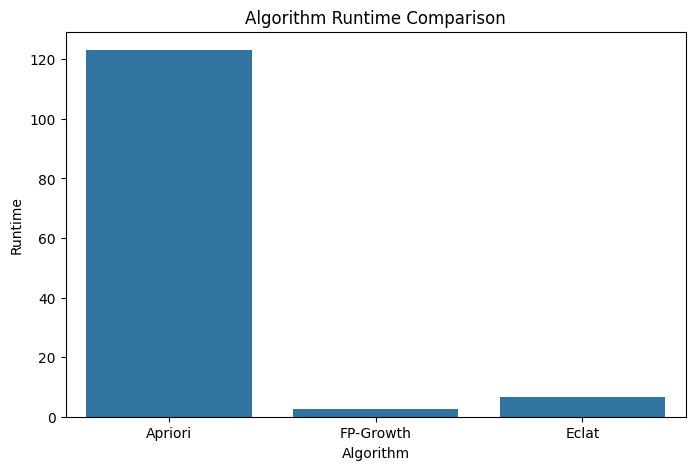

In [18]:
results = pd.DataFrame({
    'Algorithm': ['Apriori', 'FP-Growth', 'Eclat'],
    'Runtime': [
        apriori_time,
        fp_time, 
        eclat_time 
    ]
})

plt.figure(figsize=(8,5))
sns.barplot(x='Algorithm', y='Runtime', data=results)
plt.title("Algorithm Runtime Comparison")
plt.show()

In [19]:
top_rules = confidence_df.sort_values(by='Lift', ascending=False).head(10)

top_rules[['A', 'B', 'Confidence', 'Lift']]

,A,B,Confidence,Lift
268,REGENCY TEA PLATE GREEN,REGENCY TEA PLATE PINK,0.748148,61.909259
265,REGENCY MILK JUG PINK,REGENCY SUGAR BOWL GREEN,0.757353,52.381694
270,REGENCY TEA PLATE PINK,REGENCY TEA PLATE ROSES,0.879464,49.700457
269,REGENCY TEA PLATE GREEN,REGENCY TEA PLATE ROSES,0.848148,47.930714
252,POPPY'S PLAYHOUSE BEDROOM,POPPY'S PLAYHOUSE LIVINGROOM,0.648734,47.718003
287,SET/6 RED SPOTTY PAPER CUPS,SET/6 RED SPOTTY PAPER PLATES,0.828070,47.228027
253,POPPY'S PLAYHOUSE KITCHEN,POPPY'S PLAYHOUSE LIVINGROOM,0.621387,45.706487
40,CHILDRENS CUTLERY DOLLY GIRL,CHILDRENS CUTLERY SPACEBOY,0.772388,45.306915
251,POPPY'S PLAYHOUSE BEDROOM,POPPY'S PLAYHOUSE KITCHEN,0.803797,43.061242
243,PINK VINTAGE PAISLEY PICNIC BAG,SCANDINAVIAN PAISLEY PICNIC BAG,0.703180,40.859399


In [20]:
layout = {}

for _, row in top_rules.iterrows():
    layout.setdefault(row['A'], []).append(row['B'])

layout

{'REGENCY TEA PLATE GREEN ': ['REGENCY TEA PLATE PINK',
  'REGENCY TEA PLATE ROSES '],
 'REGENCY MILK JUG PINK ': ['REGENCY SUGAR BOWL GREEN'],
 'REGENCY TEA PLATE PINK': ['REGENCY TEA PLATE ROSES '],
 "POPPY'S PLAYHOUSE BEDROOM ": ["POPPY'S PLAYHOUSE LIVINGROOM ",
  "POPPY'S PLAYHOUSE KITCHEN"],
 'SET/6 RED SPOTTY PAPER CUPS': ['SET/6 RED SPOTTY PAPER PLATES'],
 "POPPY'S PLAYHOUSE KITCHEN": ["POPPY'S PLAYHOUSE LIVINGROOM "],
 'CHILDRENS CUTLERY DOLLY GIRL ': ['CHILDRENS CUTLERY SPACEBOY '],
 'PINK VINTAGE PAISLEY PICNIC BAG': ['SCANDINAVIAN PAISLEY PICNIC BAG']}

In [ ]:
print("Top Association Rules:")
display(top_rules)

# Key Insight:
# Products with high lift should be placed together to increase cross-selling.

Top Association Rules:


,A,B,Support_AB,Support_A,Confidence,Lift
268,REGENCY TEA PLATE GREEN,REGENCY TEA PLATE PINK,0.010898,0.014566,0.748148,61.909259
265,REGENCY MILK JUG PINK,REGENCY SUGAR BOWL GREEN,0.011114,0.014674,0.757353,52.381694
270,REGENCY TEA PLATE PINK,REGENCY TEA PLATE ROSES,0.010628,0.012085,0.879464,49.700457
269,REGENCY TEA PLATE GREEN,REGENCY TEA PLATE ROSES,0.012354,0.014566,0.848148,47.930714
252,POPPY'S PLAYHOUSE BEDROOM,POPPY'S PLAYHOUSE LIVINGROOM,0.011060,0.017048,0.648734,47.718003
287,SET/6 RED SPOTTY PAPER CUPS,SET/6 RED SPOTTY PAPER PLATES,0.012732,0.015375,0.828070,47.228027
253,POPPY'S PLAYHOUSE KITCHEN,POPPY'S PLAYHOUSE LIVINGROOM,0.011599,0.018666,0.621387,45.706487
40,CHILDRENS CUTLERY DOLLY GIRL,CHILDRENS CUTLERY SPACEBOY,0.011167,0.014458,0.772388,45.306915
251,POPPY'S PLAYHOUSE BEDROOM,POPPY'S PLAYHOUSE KITCHEN,0.013703,0.017048,0.803797,43.061242
243,PINK VINTAGE PAISLEY PICNIC BAG,SCANDINAVIAN PAISLEY PICNIC BAG,0.010736,0.015268,0.703180,40.859399



Key Insight:
Products with high lift should be placed together to increase cross-selling.


In [31]:
# Filter only 3-itemsets
three_itemsets = frequent_itemsets_fp[
    frequent_itemsets_fp['itemsets'].apply(lambda x: len(x) == 3)
]

three_itemsets = three_itemsets.sort_values(by='support', ascending=False)

three_itemsets.head(10)

,support,itemsets
863,0.021040,"frozenset({ROSES REGENCY TEACUP AND SAUCER , P..."
812,0.016832,"frozenset({REGENCY CAKESTAND 3 TIER, ROSES REG..."
743,0.016616,"frozenset({LUNCH BAG PINK POLKADOT, LUNCH BAG ..."
744,0.015052,"frozenset({LUNCH BAG PINK POLKADOT, LUNCH BAG ..."
860,0.014620,"frozenset({REGENCY CAKESTAND 3 TIER, PINK REGE..."
633,0.014404,"frozenset({ALARM CLOCK BAKELIKE RED , ALARM CL..."
861,0.014297,"frozenset({REGENCY CAKESTAND 3 TIER, ROSES REG..."
777,0.014135,"frozenset({LUNCH BAG RED RETROSPOT, LUNCH BAG ..."
745,0.014027,"frozenset({LUNCH BAG PINK POLKADOT, LUNCH BAG ..."
755,0.013919,"frozenset({LUNCH BAG SPACEBOY DESIGN , LUNCH B..."


In [32]:
rules_filtered = rules_fp[
    (rules_fp['confidence'] >= 0.3) &
    (rules_fp['lift'] >= 1.0) &
    (rules_fp['support'] >= 0.005)
]

rules_filtered = rules_filtered.sort_values(by='lift', ascending=False)

rules_filtered.head(10)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
577,frozenset({REGENCY TEA PLATE PINK}),frozenset({REGENCY TEA PLATE GREEN }),0.012085,0.014566,0.010898,0.901786,61.909259,1.0,0.010722,10.033507,0.995882,0.691781,0.900334,0.824967
576,frozenset({REGENCY TEA PLATE GREEN }),frozenset({REGENCY TEA PLATE PINK}),0.014566,0.012085,0.010898,0.748148,61.909259,1.0,0.010722,3.922605,0.998390,0.691781,0.745067,0.824967
394,frozenset({POPPY'S PLAYHOUSE LIVINGROOM }),"frozenset({POPPY'S PLAYHOUSE BEDROOM , POPPY'S...",0.013595,0.013703,0.010035,0.738095,53.863517,1.0,0.009848,3.765861,0.994961,0.581250,0.734456,0.735189
389,"frozenset({POPPY'S PLAYHOUSE BEDROOM , POPPY'S...",frozenset({POPPY'S PLAYHOUSE LIVINGROOM }),0.013703,0.013595,0.010035,0.732283,53.863517,1.0,0.009848,3.684512,0.995070,0.581250,0.728594,0.735189
573,frozenset({REGENCY SUGAR BOWL GREEN}),frozenset({REGENCY MILK JUG PINK }),0.014458,0.014674,0.011114,0.768657,52.381694,1.0,0.010901,4.259150,0.995300,0.616766,0.765211,0.763005
572,frozenset({REGENCY MILK JUG PINK }),frozenset({REGENCY SUGAR BOWL GREEN}),0.014674,0.014458,0.011114,0.757353,52.381694,1.0,0.010901,4.061626,0.995518,0.616766,0.753793,0.763005
392,frozenset({POPPY'S PLAYHOUSE BEDROOM }),"frozenset({POPPY'S PLAYHOUSE KITCHEN, POPPY'S ...",0.017048,0.011599,0.010035,0.588608,50.746188,1.0,0.009837,2.402575,0.997296,0.539130,0.583780,0.726862
391,"frozenset({POPPY'S PLAYHOUSE KITCHEN, POPPY'S ...",frozenset({POPPY'S PLAYHOUSE BEDROOM }),0.011599,0.017048,0.010035,0.865116,50.746188,1.0,0.009837,7.287403,0.991798,0.539130,0.862777,0.726862
578,frozenset({REGENCY TEA PLATE ROSES }),frozenset({REGENCY TEA PLATE PINK}),0.017695,0.012085,0.010628,0.600610,49.700457,1.0,0.010414,2.473559,0.997531,0.554930,0.595724,0.740037
579,frozenset({REGENCY TEA PLATE PINK}),frozenset({REGENCY TEA PLATE ROSES }),0.012085,0.017695,0.010628,0.879464,49.700457,1.0,0.010414,8.149491,0.991866,0.554930,0.877293,0.740037


In [ ]:

top_products = (
    rules_filtered['antecedents']
    .explode()
    .value_counts()
    .head(15)
    .index
)

heatmap_data = pd.DataFrame({
    'A': top_rules['antecedents'].apply(lambda x: list(x)[0]),
    'B': top_rules['consequents'].apply(lambda x: list(x)[0]),
    'Lift': top_rules['lift']
})

pivot = heatmap_data.pivot_table(
    index='A',
    columns='B',
    values='Lift',
    aggfunc='mean'  
).fillna(0)

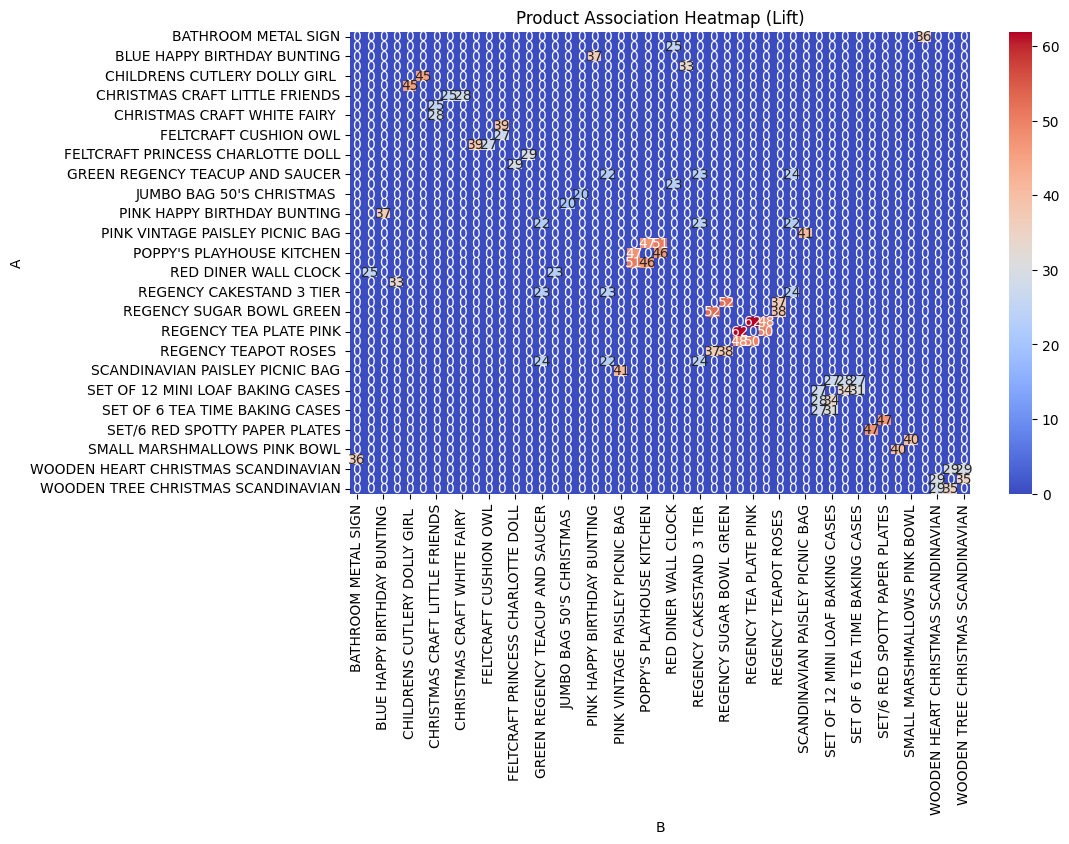

In [43]:
plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, cmap='coolwarm')
plt.title("Product Association Heatmap (Lift)")
plt.show()

In [44]:
import networkx as nx

G = nx.Graph()


G = nx.Graph()

for _, row in rules_filtered.iterrows():
    for a in row['antecedents']:
        for b in row['consequents']:
            if a in top_products and b in top_products:
                G.add_edge(a, b, weight=row['lift'])

In [47]:
from networkx.algorithms import community

communities = community.greedy_modularity_communities(G)


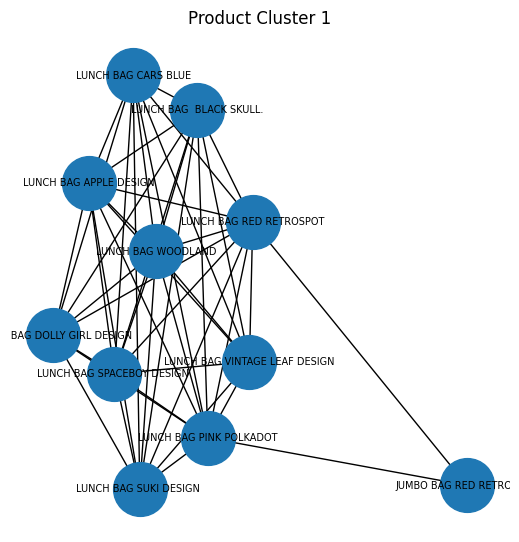

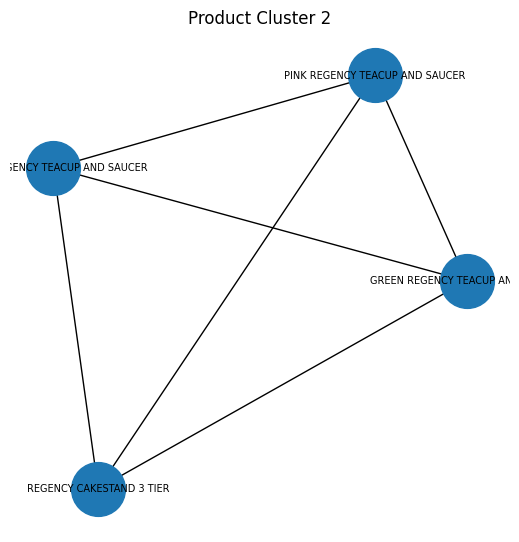

In [48]:
from networkx.algorithms import community

communities = list(community.greedy_modularity_communities(G))

for i, com in enumerate(communities):
    subgraph = G.subgraph(com)
    
    plt.figure(figsize=(5, 5))
    pos = nx.spring_layout(subgraph)
    
    nx.draw(
        subgraph, pos,
        with_labels=True,
        node_size=1500,
        font_size=7
    )
    
    plt.title(f"Product Cluster {i+1}")
    plt.show()

In [58]:
def recommend(product, rules_df, top_n=5):
    product = product.lower()
    
    recs = rules_df[
        rules_df['antecedents'].apply(lambda x: any(product in str(i).lower() for i in x)) |
        rules_df['consequents'].apply(lambda x: any(product in str(i).lower() for i in x))
    ]
    
    recs = recs.sort_values(by='lift', ascending=False)
    
    return recs[['antecedents', 'consequents', 'lift']].head(top_n)

In [59]:
print(recommend("REGENCY TEA PLATE ROSES", rules_fp))

                               antecedents                                    consequents       lift
579    frozenset({REGENCY TEA PLATE PINK})          frozenset({REGENCY TEA PLATE ROSES })  49.700457
578  frozenset({REGENCY TEA PLATE ROSES })            frozenset({REGENCY TEA PLATE PINK})  49.700457
571  frozenset({REGENCY TEA PLATE GREEN })          frozenset({REGENCY TEA PLATE ROSES })  47.930714
570  frozenset({REGENCY TEA PLATE ROSES })          frozenset({REGENCY TEA PLATE GREEN })  47.930714
567  frozenset({REGENCY TEA PLATE ROSES })  frozenset({ROSES REGENCY TEACUP AND SAUCER })  13.713049


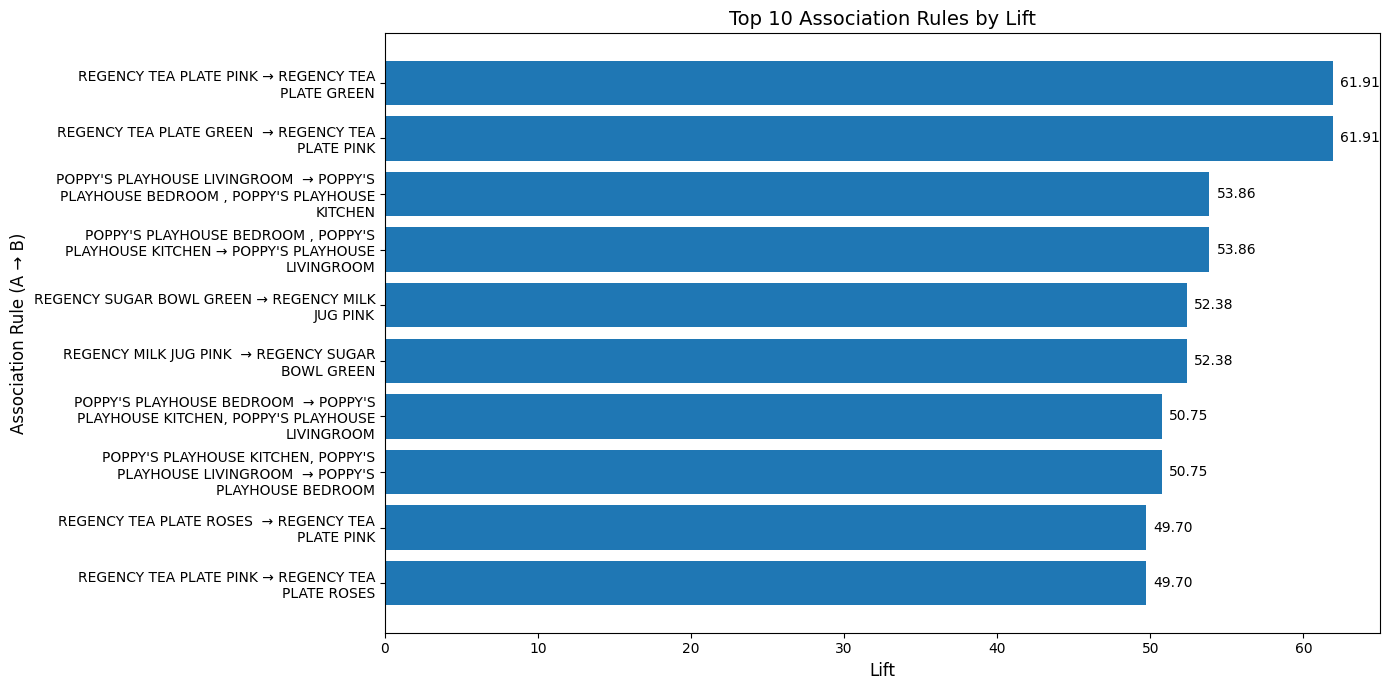

In [64]:
import textwrap

top10 = rules_filtered.sort_values(by='lift', ascending=False).head(10).copy()

top10['label'] = top10.apply(
    lambda row: f"{', '.join(list(row['antecedents']))} → {', '.join(list(row['consequents']))}",
    axis=1
)

top10['label'] = top10['label'].apply(
    lambda x: '\n'.join(textwrap.wrap(x, 40))
)

plt.figure(figsize=(14, 7))

bars = plt.barh(top10['label'], top10['lift'])

plt.gca().invert_yaxis()

plt.xlabel("Lift", fontsize=12)
plt.ylabel("Association Rule (A → B)", fontsize=12)
plt.title("Top 10 Association Rules by Lift", fontsize=14)

for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.5, bar.get_y() + bar.get_height()/2,
             f"{width:.2f}", va='center')

plt.tight_layout()
plt.show()

##### Key Insights:

1. Strong associations exist between frequently co-purchased products.
2. High lift values indicate meaningful cross-selling opportunities.
3. 3-itemsets reveal bundle combinations for marketing.
4. Network graph highlights product clusters.
5. Recommendation system can improve customer experience.